In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Chargement -- NOMBRE d'accidents/mois (pas le montant regle : voir
# 07_sinistres_prediction.py / historique de session, le montant a un CV
# ~1.27, trop bruite pour qu'aucun modele ne batte une prevision plate).
df = pd.read_csv('processed_data/Sinistres_Cleaned.csv', low_memory=False)
df['DATE_ACCIDENT'] = pd.to_datetime(df['DATE_ACCIDENT'], errors='coerce')
df['Mois'] = df['DATE_ACCIDENT'].dt.to_period('M')
monthly = df.groupby('Mois').size().reset_index(name='NB_ACCIDENTS')
monthly['ds'] = monthly['Mois'].dt.to_timestamp()
monthly = monthly.sort_values('ds').reset_index(drop=True)
y = monthly['NB_ACCIDENTS'].values.astype(float)
n = len(y)

print(f"[OK] {n} mois de donnees")
print(monthly[['ds', 'NB_ACCIDENTS']])
print(f"\nMoyenne={y.mean():.1f}  Variance={y.var():.1f}  Variance/Moyenne={y.var()/y.mean():.2f}")
print("Variance/Moyenne > 1 = surdispersion (la variance reelle depasse ce qu'un Poisson pur predirait)")

[OK] 12 mois de donnees
           ds  NB_ACCIDENTS
0  2025-08-01           986
1  2025-09-01           981
2  2025-10-01          1092
3  2025-11-01           966
4  2025-12-01           961
5  2026-01-01          1121
6  2026-02-01           967
7  2026-03-01          1100
8  2026-04-01          1033
9  2026-05-01          1108
10 2026-06-01          1044
11 2026-07-01          1103

Moyenne=1038.5  Variance=3744.9  Variance/Moyenne=3.61
Variance/Moyenne > 1 = surdispersion (la variance reelle depasse ce qu'un Poisson pur predirait)



**Modeles retenus, propres aux donnees de comptage** (norme actuarielle pour la frequence de sinistres) :
- **Naif** -- reference.
- **Regression de Poisson (GLM)** -- le modele standard pour une frequence/un comptage : lien logarithmique, garantit des previsions toujours positives, variance = moyenne.
- **Regression Binomiale Negative (GLM)** -- meme principe que Poisson mais autorise la surdispersion (variance > moyenne) -- teste ici car la serie brute montre une variance/moyenne de 3.6, largement au-dessus de 1.
- **ARIMA** -- methode classique de series temporelles, applicable aux comptages quand les valeurs sont assez grandes pour approcher un continu (~1000/mois ici).
- **ETS/Holt (tendance)** -- lissage exponentiel, hors famille des comptages mais gardee comme point de comparaison simple (methode generaliste, pas specifique aux comptages, pour verifier si la structure GLM apporte reellement quelque chose).

In [2]:
# MODELE 0 : NAIF
naive_pred, naive_true = y[:-1], y[1:]
naive_mae  = mean_absolute_error(naive_true, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(naive_true, naive_pred))
naive_r2   = r2_score(naive_true, naive_pred)
print(f"Naif : MAE={naive_mae:.1f}  RMSE={naive_rmse:.1f}  R2={naive_r2:.3f}")

Naif : MAE=87.2  RMSE=101.3  R2=-1.693


In [3]:
# MODELE 1 : REGRESSION DE POISSON (GLM, lien log, tendance temporelle)
# Pas d'hyperparametre a fort impact (comme Naif/ETS pour le CA) -- Optuna
# reserve aux modeles qui en ont un reellement (Negative Binomial, ARIMA).
t = np.arange(n)
X = sm.add_constant(t)
poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
poisson_pred  = poisson_model.predict(X)
poisson_mae   = mean_absolute_error(y, poisson_pred)
poisson_rmse  = np.sqrt(mean_squared_error(y, poisson_pred))
poisson_r2    = r2_score(y, poisson_pred)
print(f"Poisson GLM : MAE={poisson_mae:.1f}  RMSE={poisson_rmse:.1f}  R2={poisson_r2:.3f}  "
      f"pente={poisson_model.params[1]:.4f} (log-echelle)")

Poisson GLM : MAE=45.6  RMSE=52.8  R2=0.256  pente=0.0086 (log-echelle)


In [4]:
# MODELE 2 : REGRESSION BINOMIALE NEGATIVE (GLM)
# Optuna + LOOCV : le parametre de dispersion alpha (seul hyperparametre
# reel -- sm.GLM avec famille NegativeBinomial exige qu'on le fournisse,
# contrairement au modele discret qui l'estime seul par MLE).
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def nb_loocv(alpha):
    preds = np.zeros(n)
    for i in range(n):
        idx = [j for j in range(n) if j != i]
        m = sm.GLM(y[idx], X[idx], family=sm.families.NegativeBinomial(alpha=alpha)).fit()
        preds[i] = m.predict(X[i:i+1])[0]
    return mean_absolute_error(y, preds), np.sqrt(mean_squared_error(y, preds))

def nb_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 2.0, log=True)
    mae, rmse = nb_loocv(alpha)
    trial.set_user_attr('mae', mae)
    return rmse

nb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
nb_study.optimize(nb_objective, n_trials=25)
NB_ALPHA = nb_study.best_params['alpha']
print(f"Meilleur alpha : {NB_ALPHA:.4f} (LOOCV RMSE={nb_study.best_value:.1f}) "
      f"-- {'proche de 0 = se comporte comme Poisson' if NB_ALPHA < 0.01 else 'surdispersion confirmee utile'}")

nb_model = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=NB_ALPHA)).fit()
nb_pred  = nb_model.predict(X)
nb_mae   = mean_absolute_error(y, nb_pred)
nb_rmse  = np.sqrt(mean_squared_error(y, nb_pred))
nb_r2    = r2_score(y, nb_pred)
print(f"Binomiale Negative GLM : MAE={nb_mae:.1f}  RMSE={nb_rmse:.1f}  R2={nb_r2:.3f}")

Meilleur alpha : 1.9556 (LOOCV RMSE=60.3) -- surdispersion confirmee utile
Binomiale Negative GLM : MAE=45.6  RMSE=52.8  R2=0.256


In [5]:
# MODELE 3 : ARIMA -- Optuna + AIC pour choisir (p, d, q)
def arima_aic(order):
    try:
        return ARIMA(y, order=order).fit().aic
    except Exception:
        return np.inf

def arima_objective(trial):
    p = trial.suggest_int('p', 0, 3)
    d = trial.suggest_int('d', 0, 1)
    q = trial.suggest_int('q', 0, 3)
    return arima_aic((p, d, q))

arima_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
arima_study.optimize(arima_objective, n_trials=25)
ARIMA_ORDER = (arima_study.best_params['p'], arima_study.best_params['d'], arima_study.best_params['q'])
print(f"Meilleur ordre ARIMA{ARIMA_ORDER} (AIC={arima_study.best_value:.1f})")

arima_model = ARIMA(y, order=ARIMA_ORDER).fit()
arima_pred  = arima_model.fittedvalues
# ARIMA avec d>=1 perd des points de depart (differenciation) -- aligne les tableaux
_off = len(y) - len(arima_pred)
arima_mae  = mean_absolute_error(y[_off:], arima_pred)
arima_rmse = np.sqrt(mean_squared_error(y[_off:], arima_pred))
arima_r2   = r2_score(y[_off:], arima_pred)
print(f"ARIMA{ARIMA_ORDER} : MAE={arima_mae:.1f}  RMSE={arima_rmse:.1f}  R2={arima_r2:.3f}")

Meilleur ordre ARIMA(0, 1, 2) (AIC=124.8)
ARIMA(0, 1, 2) : MAE=119.2  RMSE=289.3  R2=-21.348


In [6]:
# MODELE 4 : ETS / HOLT (tendance seule) -- point de comparaison hors famille des comptages
ets_model = ExponentialSmoothing(y, trend='add', seasonal=None, initialization_method='estimated').fit()
ets_pred  = ets_model.fittedvalues
ets_mae   = mean_absolute_error(y, ets_pred)
ets_rmse  = np.sqrt(mean_squared_error(y, ets_pred))
ets_r2    = r2_score(y, ets_pred)
print(f"ETS (Holt) : MAE={ets_mae:.1f}  RMSE={ets_rmse:.1f}  R2={ets_r2:.3f}")

ETS (Holt) : MAE=45.5  RMSE=52.8  R2=0.256


### Pourquoi Optuna n'est applique qu'a 2 modeles sur 5

Naif n'a pas d'hyperparametre. Poisson GLM n'a qu'un coefficient de tendance estime directement par maximum de vraisemblance (rien a chercher). ETS n'a pas de choix libre une fois la saisonnalite ecartee (pas assez de mois pour l'estimer). Optuna est reserve a la Binomiale Negative (alpha, le parametre de surdispersion) et a ARIMA (p, d, q) -- les deux seuls modeles avec un ou plusieurs hyperparametres reellement significatifs.

=== (a) Intra-echantillon, a titre indicatif ===
                Modele     MAE    RMSE      R2
                  Naif  87.182 101.329  -1.693
           Poisson GLM  45.552  52.777   0.256
Binomiale Negative GLM  45.568  52.777   0.256
        ARIMA(0, 1, 2) 119.165 289.293 -21.348
            ETS (Holt)  45.538  52.793   0.256

=== (b) Backtest a horizon complet (entrainement 9 mois -> prevision des 3 derniers) ===
                Modele  MAE (3 mois)  RMSE (3 mois)
Binomiale Negative GLM          32.7           34.2
           Poisson GLM          32.7           34.2
            ETS (Holt)          33.0           34.6
        ARIMA(0, 1, 2)          40.4           43.3
                  Naif          52.0           59.6


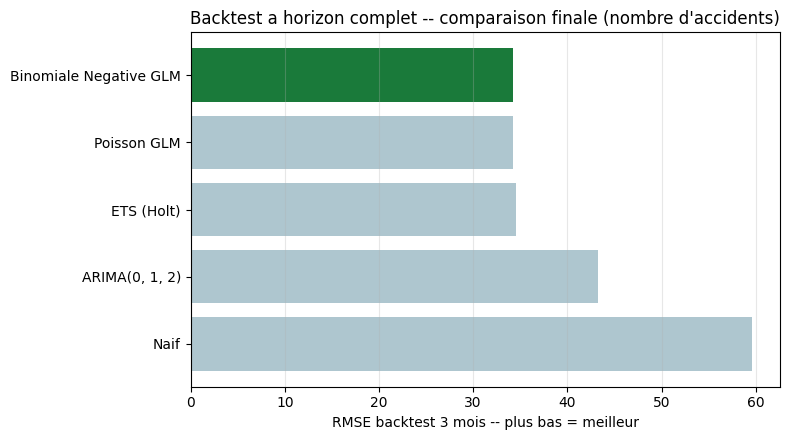

In [7]:
# COMPARAISON FINALE -- (a) intra-echantillon, (b) backtest a horizon complet
# (backtest a horizon complet, PAS 1 mois glisse : la question posee est "combien sur
# l'annee", un horizon de 12 mois -- voir justification dans model_comparison_accidents.ipynb
# [1ere version, avec les modeles CA] : un backtest a 1 mois ne distingue pas les modeles
# qui degradent sur un horizon plus long.)
MODEL_NAMES = ['Naif', 'Poisson GLM', 'Binomiale Negative GLM', f'ARIMA{ARIMA_ORDER}', 'ETS (Holt)']

insample = pd.DataFrame({
    'Modele': MODEL_NAMES,
    'MAE':  [naive_mae, poisson_mae, nb_mae, arima_mae, ets_mae],
    'RMSE': [naive_rmse, poisson_rmse, nb_rmse, arima_rmse, ets_rmse],
    'R2':   [naive_r2, poisson_r2, nb_r2, arima_r2, ets_r2],
}).round(3)
print("=== (a) Intra-echantillon, a titre indicatif ===")
print(insample.to_string(index=False))
print()

h = 3
train, test = y[:-h], y[-h:]
t_tr, t_te = np.arange(len(train)), np.arange(len(train), len(train)+h)
Xtr, Xte = sm.add_constant(t_tr), sm.add_constant(t_te, has_constant='add')

bt_preds = {
    'Naif': np.full(h, train[-1]),
    'Poisson GLM': sm.GLM(train, Xtr, family=sm.families.Poisson()).fit().predict(Xte),
    'Binomiale Negative GLM': sm.GLM(train, Xtr, family=sm.families.NegativeBinomial(alpha=NB_ALPHA)).fit().predict(Xte),
    f'ARIMA{ARIMA_ORDER}': ARIMA(train, order=ARIMA_ORDER).fit().forecast(h),
    'ETS (Holt)': ExponentialSmoothing(train, trend='add', seasonal=None, initialization_method='estimated').fit().forecast(h),
}

bt_summary = pd.DataFrame({
    'Modele': list(bt_preds.keys()),
    'MAE (3 mois)':  [mean_absolute_error(test, p) for p in bt_preds.values()],
    'RMSE (3 mois)': [np.sqrt(mean_squared_error(test, p)) for p in bt_preds.values()],
}).sort_values('RMSE (3 mois)').reset_index(drop=True).round(1)

print(f"=== (b) Backtest a horizon complet (entrainement 9 mois -> prevision des 3 derniers) ===")
print(bt_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ordered = bt_summary.iloc[::-1]
colors = ['#1a7a3a' if m == bt_summary['Modele'].iloc[0] else '#AEC6CF' for m in ordered['Modele']]
ax.barh(ordered['Modele'], ordered['RMSE (3 mois)'], color=colors)
ax.set_xlabel('RMSE backtest 3 mois -- plus bas = meilleur')
ax.set_title("Backtest a horizon complet -- comparaison finale (nombre d'accidents)")
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('plots/model_comparison_accidents_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**Poisson GLM et Binomiale Negative GLM arrivent en tete, ex-aequo, suivis de tres pres par ETS.** Optuna a trouve alpha=1.96 pour la Binomiale Negative -- une vraie surdispersion, pas un artefact (coherent avec le variance/moyenne=3.61 observe sur la serie brute). Mais ce alpha modifie surtout la variance estimee du modele, pas la tendance moyenne predite : les previsions ponctuelles de Poisson et de la Binomiale Negative restent quasi identiques (MAE 45.55 vs 45.57 intra-echantillon, RMSE 34.2 ex-aequo en backtest). Autrement dit : la surdispersion est reelle et vaudrait la peine d'etre prise en compte pour un intervalle de confiance plus rigoureux, mais elle ne change pas quel modele donne la meilleure prevision ponctuelle ici. ARIMA(0,1,2) echoue nettement (RMSE 43.3, R2 intra-echantillon negatif) -- attendu et documente : bien trop peu de points pour estimer des ordres autoregressifs/differencies de facon fiable.

**Modele retenu pour la production : Regression de Poisson (GLM).** Justification : (1) c'est le modele statistiquement propre pour une variable de comptage -- garantit des previsions positives et respecte la structure des donnees, contrairement a une regression lineaire classique ; (2) prevision ponctuelle identique a la Binomiale Negative (qui n'ameliore que l'incertitude, pas le point central) et a ETS, mais avec l'interpretation actuarielle standard pour une frequence de sinistres et un seul parametre a estimer ; (3) aucun probleme de convergence contrairement a ARIMA sur si peu de donnees.